# Insert atmosphere model

In [1]:
from pyaat.atmosphere import atmosISA, atmosCOESA,SimplifiedModel, seaLevel

### Compare values at sea level

In [2]:
atm1 = atmosISA()
atm2 = atmosCOESA()
atm3 = SimplifiedModel()
atm4 = seaLevel()

atm1._altitude = 0.
atm2._altitude = 0.
atm3._altitude = 0.
atm4._altitude = 0.

print('rho- ISA model')
print(atm1._rho)
print('-----------------')
print('rho- COESA model')
print(atm2._rho)
print('-----------------')
print('rho- Cook model')
print(atm3._rho)
print('-----------------')
print('rho- Lewis')
print(atm4._rho)

rho- ISA model
1.2246977728693844
-----------------
rho- COESA model
1.225000018124288
-----------------
rho- Cook model
1.225
-----------------
rho- Lewis
1.225


### Compute values for pressure, temperature and air density for a range of altitudes

In [3]:
from numpy import arange
import matplotlib.pyplot as plt

In [4]:
hlist_low = arange(0,12192,10) # Atmosphere ISA is only valid for values h<=12192
hlist_high = arange(0,86000,10) 
r1 = []
r2 = []
r3 = []

p1 = []
p2 = []

t1 = []
t2 = []
t3 = []

In [5]:
for h in hlist_low:
    atm1._altitude = h
    atm3._altitude = h

    r1.append(atm1._rho)    
    t1.append(atm1._temperature)
    t3.append(atm3._temperature)

    p1.append(atm1._pressure)

    
for h in hlist_high:
    atm2._altitude = h
    atm3._altitude = h
    
    r2.append(atm2._rho)
    r3.append(atm3._rho)
    t2.append(atm2._temperature)

    p2.append(atm2._pressure)

/home/ydor9e/.local/lib/python3.9/site-packages/pyaat/atmosphere.py:134: RuntimeWarning: invalid value encountered in double_scalars
  return RHO_SEA *(self._temperature/288.16)**(-(GRAVITY/(self._Ir*R_AIR)+1))


### Air density

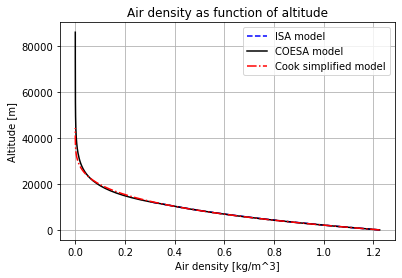

In [6]:
plt.figure()
plt.plot(r1,hlist_low, label = 'ISA model', color = 'b', linestyle = '--')
plt.plot(r2,hlist_high, label = 'COESA model', color = 'k', linestyle = '-')
plt.plot(r3, hlist_high, label = 'Cook simplified model', color = 'r', linestyle = '-.')
plt.xlabel('Air density [kg/m^3]')
plt.ylabel('Altitude [m]')
plt.title('Air density as function of altitude')
plt.legend()
plt.grid()
plt.show()

### Temperature

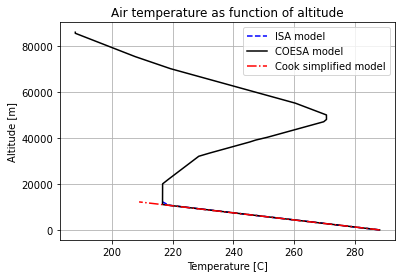

In [7]:
plt.figure()
plt.plot(t1,hlist_low, label = 'ISA model', color = 'b', linestyle = '--')
plt.plot(t2,hlist_high, label = 'COESA model', color = 'k', linestyle = '-')
plt.plot(t3, hlist_low, label = 'Cook simplified model', color = 'r', linestyle = '-.')
plt.xlabel('Temperature [C]')
plt.ylabel('Altitude [m]')
plt.title('Air temperature as function of altitude')
plt.legend()
plt.grid()
plt.show()

### Pressure

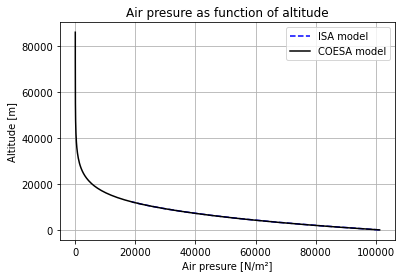

In [8]:
plt.figure()
plt.plot(p1,hlist_low, label = 'ISA model', color = 'b', linestyle = '--')
plt.plot(p2,hlist_high, label = 'COESA model', color = 'k', linestyle = '-')
plt.xlabel('Air presure [N/m²]')
plt.ylabel('Altitude [m]')
plt.title('Air presure as function of altitude')
plt.legend()
plt.grid()
plt.show()